# Exploratory Data Analysis (Deep Learning Dataset)
This notebook explores the processed `dl_30_features_data.csv` prepared for N-BEATS and Chronos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df = pd.read_csv("data/processed/dl_30_features_data.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,Mandi,Commodity,ModalPrice,target_price,Arrivals,day_of_year,day_of_week,month,year,...,rolling_mean_7,rolling_std_7,price_range,volatility_7,momentum_7,arrivals_lag_1,arrivals_lag_7,arrival_change_7,temp_anomaly,rain_anomaly
0,2025-07-01,A lot APMC,Onion,690.0,900.0,14.77,182,1,7,2025,...,620.142857,192.613974,880.0,0.310596,0.985714,11.82,3.21,4.601246,-2.089333,-3.798667
1,2025-07-03,A lot APMC,Onion,900.0,350.0,2.04,184,3,7,2025,...,661.571429,219.394513,590.0,0.331626,1.475410,14.77,3.25,0.627692,-2.324375,-6.073750
2,2025-07-04,A lot APMC,Onion,350.0,351.0,13.79,185,4,7,2025,...,611.571429,247.286512,550.0,0.404346,0.500000,2.04,5.74,2.402439,-1.641765,-8.784706
3,2025-07-05,A lot APMC,Onion,351.0,200.0,4.36,186,5,7,2025,...,544.428571,244.739220,465.0,0.449534,0.427527,13.79,3.12,1.397436,-2.032222,1.289444
4,2025-07-08,A lot APMC,Onion,200.0,201.0,18.33,189,1,7,2025,...,458.714286,245.380463,810.0,0.534931,0.250000,4.36,6.92,2.648844,-1.025263,-10.061579


In [2]:
print(f"Total Rows: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"Date Range: {df.date.min().date()} to {df.date.max().date()}")
print("\nMissing values:", df.isna().sum().sum())

Total Rows: 733919
Total Features: 35
Date Range: 2025-06-12 to 2026-04-19

Missing values: 0


/var/folders/0d/m9v72c4552s42lxq70jj8qlh0000gn/T/ipykernel_30758/169822174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Commodity", order=df["Commodity"].value_counts().index, palette="viridis")


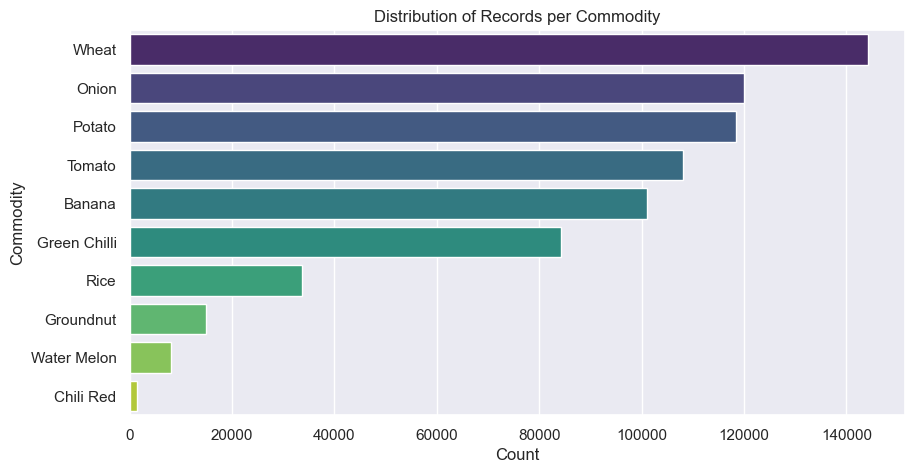

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="Commodity", order=df["Commodity"].value_counts().index, palette="viridis")
plt.title("Distribution of Records per Commodity")
plt.xlabel("Count")
plt.show()

### Modal Price Distributions
Looking at the statistical spread and outliers of our target variable `target_price`.

count    733919.000000
mean       2746.449575
std        1856.857695
min           0.300000
25%        1500.000000
50%        2456.000000
75%        3320.000000
max       63000.000000
Name: target_price, dtype: float64


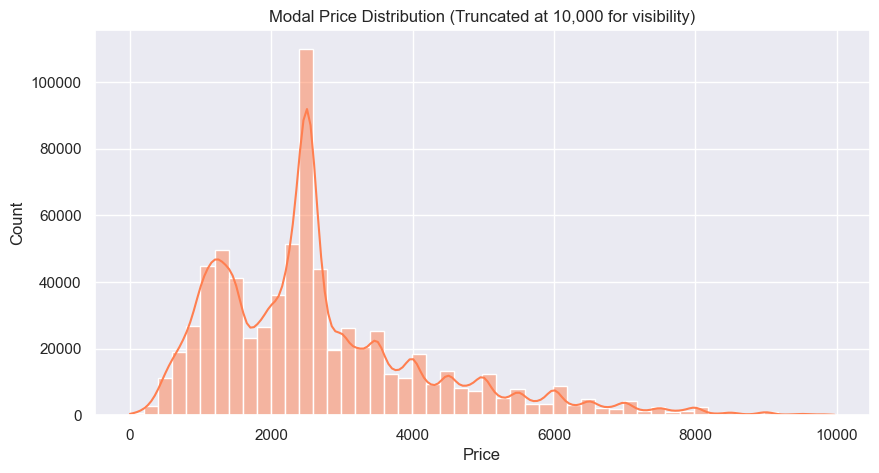

In [4]:
print(df["target_price"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df[df["target_price"] < 10000]["target_price"], bins=50, kde=True, color="coral")
plt.title("Modal Price Distribution (Truncated at 10,000 for visibility)")
plt.xlabel("Price")
plt.show()

In [5]:
# Let us visualize the price trend for Wheat in a specific Mandi
wheat_df = df[(df["Commodity"] == "Wheat") & (df["Mandi"] == "Ambala City")].sort_values("date")
if not wheat_df.empty:
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=wheat_df, x="date", y="ModalPrice")
    plt.title("Wheat Prices over Time (Ambala City)")
    plt.ylabel("Price")
    plt.show()